In [3]:
import numpy as np
import pyuvdata
import matplotlib.pyplot as plt

In [14]:
timestamps = ["112543", "112553", "112603", "112613", "112623", "112633"]
use_freq_interval = np.array([28352050.78125, 41295898.4375])

uv_list = []
for use_timestamp in timestamps:
    freq_bands = [27, 32, 36, 41]
    for freq_ind, freq in enumerate(freq_bands):
        uv_new = pyuvdata.UVData()
        uv_new.read(f"/lustre/pipeline/cosmology/{freq}MHz/2026-04-19/11/20260419_{use_timestamp}_{freq}MHz.ms", data_column="DATA")
        uv_new.select(ant_str="auto")
        if freq_ind == 0:
            uv = uv_new
        else:
            uv.fast_concat(uv_new, "freq", inplace=True)

    use_freq = [freq for freq in uv.freq_array if np.min(use_freq_interval) <= freq <= np.max(use_freq_interval)]
    uv.select(frequencies=use_freq)
    uv_list.append(uv)


Setting telescope_location to value in known_telescopes for OVRO-LWA.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 5.8806211606770376 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Setting telescope_location to value in known_telescopes for OVRO-LWA.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 5.880564031718222 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Setting telescope_location to value in known_telescopes for OVRO-LWA.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 5.88062842662066 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
Setting telescope_location to value in known_telescopes fo

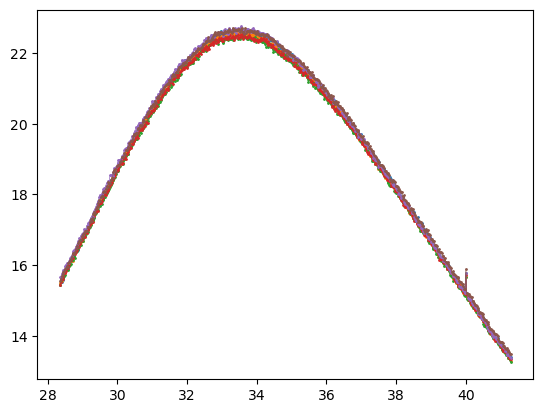

In [16]:
for uv in uv_list:
    uv_single_ant = uv.select(antenna_names=["LWA001"], inplace=False)
    plt.plot(uv_single_ant.freq_array/1e6, np.abs(uv_single_ant.data_array[0,:,1]), ".-", markersize=2, linewidth=0.5, label="gain")
plt.show()

In [19]:
def detrend(x, y):
    idx = np.isfinite(x) & np.isfinite(y)
    coeffs = np.polyfit(x[idx], y[idx], 2)
    y_new = y - np.poly1d(coeffs)(x)
    return y_new

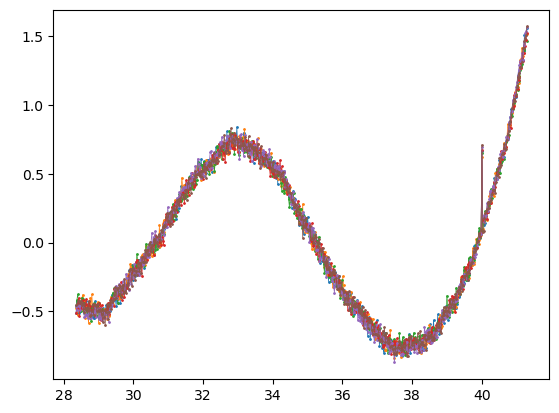

In [20]:
for uv in uv_list:
    uv_single_ant = uv.select(antenna_names=["LWA001"], inplace=False)
    data_detrended = detrend(uv_single_ant.freq_array, np.abs(uv_single_ant.data_array[0,:,1]))
    plt.plot(uv_single_ant.freq_array/1e6, data_detrended, ".-", markersize=2, linewidth=0.5, label="gain")
plt.show()